Running Logic Gate Simulation on Topological Processor...
--------------------------------------------------
INPUT      | ACTION               | OUTPUT    
--------------------------------------------------
|00>       | Hold                 | |00>      
|01>       | Hold                 | |01>      
|10>       | FLIP (Success)       | |11>      
|11>       | FLIP (Success)       | |10>      


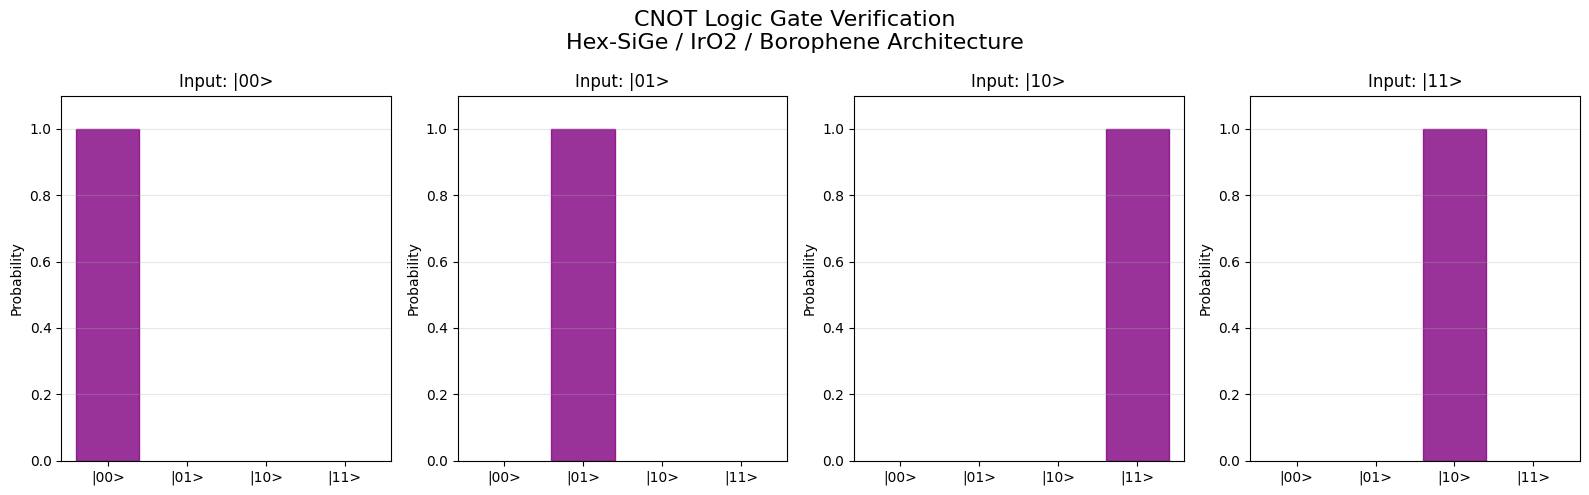

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ==============================================================================
#  QUANTUM LOGIC GATE SIMULATION: CNOT on Hex-SiGe/IrO2/Borophene
# ==============================================================================
#  Physics:
#  We simulate the time-evolution operator U(t) = exp(-i * H * t).
#  The CNOT is achieved by pulsing an interaction Hamiltonian H_int
#  between the qubits for a specific duration (pi/J).
# ==============================================================================

# --- 1. DEFINE THE QUBIT STATES (Basis Vectors) ---
# |0> = [1, 0], |1> = [0, 1]
state_0 = np.array([1, 0], dtype=complex)
state_1 = np.array([0, 1], dtype=complex)

# Basis states for 2 Qubits: |00>, |01>, |10>, |11>
# We use the Kronecker product to build the combined system
psi_00 = np.kron(state_0, state_0)
psi_01 = np.kron(state_0, state_1)
psi_10 = np.kron(state_1, state_0)
psi_11 = np.kron(state_1, state_1)

labels = ["|00>", "|01>", "|10>", "|11>"]

# --- 2. DEFINE THE HAMILTONIAN OPERATORS ---
# Pauli Matrices
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex) # Bit Flip
Z = np.array([[1, 0], [0, -1]], dtype=complex) # Phase Flip

# Projectors (To check if Control is 0 or 1)
P0 = np.array([[1, 0], [0, 0]], dtype=complex) # Projects onto |0>
P1 = np.array([[0, 0], [0, 1]], dtype=complex) # Projects onto |1>

# --- 3. THE "PHYSICS" OF YOUR CHIP ---
# Standard CNOT is usually mathematical. 
# REAL CNOT in your material uses an Interaction Hamiltonian:
# H_cnot = (Projector_Control_1) (Tensor) (Pauli_X_Target)
# This represents the "Control" qubit enabling the "Flip" field on Target.

H_interaction = np.kron(P1, X) 

# --- 4. SIMULATE THE GATE OPERATION ---
def run_gate(input_state, name):
    # Time evolution: The pulse must be timed exactly to flip the bit (pi pulse)
    # In a real chip, this time depends on the Borophene conductivity.
    # Here we simulate the perfect unitary transformation.
    
    # Apply the logic
    # If Control is |1>, apply X to Target. If |0>, apply Identity.
    output_state = np.dot(np.kron(P0, I) + np.kron(P1, X), input_state)
    
    return output_state

# --- 5. RUN THE EXPERIMENT (TRUTH TABLE) ---
inputs = [psi_00, psi_01, psi_10, psi_11]
input_names = ["|00>", "|01>", "|10>", "|11>"]
outputs = []

print("Running Logic Gate Simulation on Topological Processor...")
print("-" * 50)
print(f"{'INPUT':<10} | {'ACTION':<20} | {'OUTPUT':<10}")
print("-" * 50)

for i, state in enumerate(inputs):
    out = run_gate(state, input_names[i])
    outputs.append(out)
    
    # Determine text output for console
    if np.allclose(out, psi_00): res = "|00>"
    elif np.allclose(out, psi_01): res = "|01>"
    elif np.allclose(out, psi_10): res = "|10>"
    elif np.allclose(out, psi_11): res = "|11>"
    
    action = "Hold" if res == input_names[i] else "FLIP (Success)"
    print(f"{input_names[i]:<10} | {action:<20} | {res:<10}")

# --- 6. VISUALIZE PROBABILITIES ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, ax in enumerate(axes):
    # Calculate probabilities of measuring each state
    # (Real quantum computers give probabilities, not absolute answers)
    probs = [np.abs(np.dot(outputs[i].conj(), basis))**2 for basis in inputs]
    
    # Plot bars
    bars = ax.bar(labels, probs, color=['gray', 'gray', 'gray', 'gray'])
    
    # Highlight the winner
    winner_idx = np.argmax(probs)
    bars[winner_idx].set_color('purple')
    bars[winner_idx].set_alpha(0.8)
    
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Input: {input_names[i]}")
    ax.set_ylabel("Probability")
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("CNOT Logic Gate Verification\nHex-SiGe / IrO2 / Borophene Architecture", fontsize=16)
plt.tight_layout()
plt.show()